# Gradient Descent

## Theorem: The Gradient is the Direction of Maximal Increase
  
If $f : \mathbb{R}^n \to \mathbb{R}$ is differentiable at $x$, then:

1. For every unit vector $u$,
   $$
   D_u f(x) = \nabla f(x) \cdot u.
   $$
   where $D_u f$ denotes the derivative of $f$ in the direction of $u$.

2. Among all unit vectors $u$, the quantity $D_u f(x)$ is maximized when  
   $$
   u = \frac{\nabla f(x)}{\|\nabla f(x)\|} \quad (\nabla f(x) \neq 0),
   $$  
   and the maximal value is  
   $$
   \max_{\|u\| = 1} D_u f(x) = \|\nabla f(x)\|.
   $$

3. Among all unit vectors $u$, the quantity $D_u f(x)$ is minimized when  
   $$
   u = -\frac{\nabla f(x)}{\|\nabla f(x)\|} \quad (\nabla f(x) \neq 0),
   $$  
   and the minimal value is  
   $$
   \min_{\|u\| = 1} D_u f(x) = -\|\nabla f(x)\|.
   $$



**Proof 1:**. Directional derivative as inner product

For a unit vector $u \in \mathbb{R}^n$, the directional derivative of $f$ at $x$ in the direction $u$ is defined as:

$$
D_u f(x) = \lim_{h \to 0} \frac{f(x + h u) - f(x)}{h}.
$$

Since $f$ is differentiable at $x$, we have the first-order expansion:

$$
f(x + h u) = f(x) + h \, \nabla f(x) \cdot u + o(h).
$$

Thus:

$$
\frac{f(x + h u) - f(x)}{h}
= \nabla f(x) \cdot u + \frac{o(h)}{h}.
$$

Taking $h \to 0$ gives:

$$
D_u f(x) = \nabla f(x) \cdot u.
$$

**Proof 2,3:** 

By applying the Cauchy–Schwarz inequality to the equality in (1.), for any unit vector $u$, we have

$$
|D_u f(x)|= |\nabla f(x)\cdot u| \le \|\nabla f(x)\| \, \|u\| = \|\nabla f(x)\|.
$$

Thus,

$$
-\|\nabla f(x)\| \le D_u f(x) \le \|\nabla f(x)\|, \quad \forall u : \|u\| = 1.
$$
In addition equality in Cauchy–Schwarz holds if and only if $v = \alpha \nabla f(x)$, for some $\alpha\in \mathbb{R}$. Since $\|v\|=1$, we get $|\alpha|=\frac{1}{\|\nabla f(x)\|}$ and consequently $\alpha=\pm \frac{1}{\|\nabla f(x)\|}$. So, maximum and minimum are achieved only at $v_{1,2}= \pm \frac{\nabla f(x)}{\|\nabla f(x)\|}$. By simple evaluation we get the result
$$
D_{v_{1,2}} f(x)=\nabla f(x)^{T}\cdot \frac{\pm\nabla f(x)}{\|\nabla f(x)\|}=\pm\frac{\|\nabla f(x)\|^2}{\|\nabla f(x)\|}= \pm\|\nabla f(x)\|.
$$

## Definition: Gradient Descent 
We want to minimize a loss function

$$
L(\theta|\{x_i,y_i\}_{i=1}^{N}) = \frac{1}{N} \sum_{i=1}^N \ell(\theta| x_i, y_i).
$$


### 1. Full-Batch Gradient Descent 

$$
\theta_{t+1} = \theta_t - \eta_t \, \nabla_\theta L(\theta_t).
$$

### 2. Stochastic Gradient Descent (single sample)

At iteration $t$, pick a random index $i_t \sim \{1,\dots,N\}$:

$$
\theta_{t+1}
= \theta_t - \eta_t \, \nabla_\theta \ell(\theta_t; x_{i_t}, y_{i_t}).
$$

###  3. Mini-Batch Stochastic Gradient Descent

Take a random set of index $B_t\subset\{1,2,\dots,N\}$ of size $m$:

$$
\theta_{t+1}
= \theta_t
- \eta_t \, \frac{1}{|B_t|}
  \sum_{i \in B_t}
  \nabla_\theta \ell(\theta_t; x_i, y_i).
$$

### Property: Gradient Variance decreases with batch size

Let's denote by $\mathcal{B}_i$ the $i$-th batch which is uniformly randomly selected and each sample $(X,Y)=(x,y)$ is uniformly randomly selected in the batch. Let's denote $\sigma^2_{S}$ and $\sigma^2_{MB}$ the variances of the SGD and mini-batch GD algorithms respectively  

$$
\begin{align*}
\sigma^2_{S}&=\mathbb{V}\left[\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right],\\
\sigma^2_{MB}&=\mathbb{V}\left[\mathbb{E}\left[\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right| X,Y \in \mathcal{B}_i\right]\right].
\end{align*}
$$
Then
$$
\begin{align*}
\sigma^2_{S}\ge \sigma^2_{MB}.
\end{align*}
$$

**Proof:** Consither the random variable
$$
\begin{align*}
Z(i) = \mathbb{E}\left[\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right| X,Y \in \mathcal{B}_i\right],
\end{align*}
$$
where $\ell$ is the loss funciton and $\theta$ are the learnable model parameters.

From the Law of total expectation, we have

$$
\begin{align*}
\mathbb{E}\left[\mathbb{E}\left[\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right| X,Y \in \mathcal{B}_i\right]\right]=\mathbb{E}\left[\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right],
\end{align*}
$$

then we have that the variance of minibatch-SGD is 
$$
\begin{align*}
\sigma^2_{MB}&=\mathbb{E}[(Z-\mathbb{E}[Z])^2]=\mathbb{E}[Z^2]-\mathbb{E}[Z]^2,\\
&=\mathbb{E}\left[\left(\mathbb{E}\left[\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right| X,Y \in \mathcal{B}_i\right]\right)^2\right]-\mathbb{E}\left[\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right]^2
\end{align*}
$$

If we take bathch_size = 1, then $X,Y\in\mathcal{B}_i$ is deterministic and  we get that the SGD variance is 

$$
\begin{align*}
\sigma^2_{S}&=\mathbb{E}\left[\left(\mathbb{E}\left[\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right| X,Y \in \mathcal{B}_i\right]\right)^2\right]-\mathbb{E}\left[\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right]^2,\\
&=\mathbb{E}\left[\left(\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right)^2\right]-\mathbb{E}\left[\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right]^2
\end{align*}
$$

Then, the variance reduction is

$$
\begin{align*}
\sigma^2_{S}-\sigma_{MB}^2&=\mathbb{E}\left[\left(\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right)^2\right]- \mathbb{E}\left[\left(\mathbb{E}\left[\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right| X,Y \in \mathcal{B}_i\right]\right)^2\right],\\
&\geq \mathbb{E}\left[\left(\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right)^2\right]- \mathbb{E}\left[\mathbb{E}\left[\left(\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right)^2\right| X,Y \in \mathcal{B}_i\right]\right],\\
&= \mathbb{E}\left[\left(\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right)^2\right]- \mathbb{E}\left[\left(\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right)^2\right],\\
&=0.
\end{align*}
$$

Then we have proved that minibatch GD never increases the variance of SGD: $\sigma^2_{S}\geq \sigma^2_{MB}$.

## Definition: SGD with Momentum

We consider a loss function $L(\theta)$ and its (stochastic) gradient at step $t$,
$$
g_t = \nabla_\theta L(\theta_t),
$$
where the gradient acts like a force that pushes the velocity in the descent direction.

Momentum introduces a **velocity** vector $v_t$ that accumulates past forces, giving the update a physics-like interpretation:
$$
\begin{align*}
v_0 &= 0,\\[4pt]
v_{t+1} &= \mu v_t + g_t,\\[4pt]
\theta_{t+1} &= \theta_t - \eta\, v_{t+1},
\end{align*}
$$

where $\eta > 0$ is the learning rate and $\mu \in [0,1)$ controls how much past velocity is preserved.

### Property: Old gradients are exponentially forgotten (their weight decays like $\alpha^k$).
$$
v_{n+1} = \sum_{i=0}^n \mu^{n-i} g_{i}
$$
Intuitively, momentum lets the optimizer “build up speed” in directions where many gradients agree, which reduces zig-zagging and speeds up progress through flat regions.

**Proof:** Let's prove it by induction on $n$. 

For $n=0$, we have $v_{1}=\mu v_0+g_0=g_0$ on the left side, and on the right side we have 
$$\sum_{i=0}^0\mu^{0-i}g_{i}=\mu^{0-0}g_0=g_0,$$
so the equality is true for $n=0$.

Let's prove the induction step, assume the equation is true for $n-1$, then we have

$$
\begin{align*}
v_{n+1} &= \mu v_{n} + g_{n},\\
&= \mu\sum_{i=0}^{n-1} \mu^{n-1-i} g_i + g_{n},\\
&= \sum_{i=0}^{n-1} \mu^{n-i} g_i+ 
u^0g_{n},\\
&= \sum_{i=0}^{n} \mu^{n-i} g_i.
\end{align*}
$$
so it is also true for $n$ and the inducion is completed.

## Definition: SGD with damped momentum
Dampening scales down the new gradient in the momentum update, making the step less aggressive. In practice, dampening is rarely needed in modern deep learning because the learning rate and momentum hyperparameters already provide equivalent control. It remains mostly for historical completeness rather than mathematical necessity.

$$
v_{t+1} = \mu v_t + (1 - \delta) g_t,
\qquad v_0 = 0,
$$

## Definition: SGD with Nesterov Momentum

Nesterov momentum improves classical momentum by *predicting* where momentum is about to move the parameters and then computing the gradient at that “future” position. This anticipatory step makes the correction earlier and more accurate, which reduces overshooting and typically leads to faster convergence.

We first compute the look-ahead position (before applying the new gradient):
$$
\hat\theta_t = \theta_t - \eta \mu v_t.
$$

We then compute the gradient at this look-ahead point:
$$
\hat{g}_t = \nabla_\theta L(\hat\theta_t).
$$

Finally, we update the velocity and the parameters just like in classical momentum:
$$
\begin{align*}
v_{t+1} &= \mu v_t + \hat{g}_t,\\
\theta_{t+1} &= \theta_t - \eta\, v_{t+1}.
\end{align*}
$$


## PyTorch’s Nesterov-Style Algorithm

The update implemented in PyTorch when `nesterov=True` is **not** the classical
Nesterov Accelerated Gradient (NAG). It is a **Nesterov-style momentum
heuristic**: inspired by the idea of looking ahead, but not mathematically
derived from the original algorithm.

PyTorch does **not** compute the displaced gradient $\hat g_t$. Instead, it uses
the usual gradient $g_t = \nabla L(\theta_t)$ and applies the heuristic update:
$$
\begin{align*}
d_t &= g_t + \mu v_{t+1},\\
\theta_{t+1} &= \theta_t - \eta\, d_t.
\end{align*}
$$

This rule is **not** an approximation of true Nesterov and is **not**
mathematically equivalent. It is an engineering shortcut (Sutskever et al.,
2013) that imitates the early-correction behavior of Nesterov without having
to temporarily move the parameters to a look-ahead position and restore them,
which would require copying all model weights every iteration.

Deep-learning libraries (PyTorch, TensorFlow, JAX, Keras) use this variant
because it is cheap, simple, and empirically improves stability compared to
classical momentum, even though it is not the original NAG method.

## Definition Weight decay (L2 regularization)

Weight decay (L2 regularization) helps prevent overfitting by discouraging very large weights. Large parameters make the model overly sensitive to small input changes, producing unstable predictions. Penalizing weight magnitude keeps the model smoother and more stable. This is achieved by adding a small L2 penalty to the loss:
$$
L_{\text{reg}}(\theta)=L(\theta)+\frac{\lambda}{2}\|\theta\|^2.
$$
where $\lambda \ge 0$ is the weight decay coefficient.

### Property
$$
\nabla_\theta L_{\text{reg}}(\theta)
= \nabla_\theta L(\theta) + \lambda\,\theta.
$$

**Proof:**
Since gradient is a linear operator we have
$$
\begin{align*}
\nabla_\theta L_{\text{reg}}(\theta)
&= \nabla_\theta \left(L(\theta) +\frac{\lambda}{2}\|\theta\|^2\right),\\
&= \nabla_\theta \left(L(\theta)\right) + \frac{\lambda}{2}\nabla_\theta \left(\|\theta\|^2\right),\\
&= \nabla_\theta L(\theta) +\frac{\lambda}{2}\left(2\theta\right),\\
&= \nabla_\theta L(\theta) + \lambda\theta.
\end{align*}
$$

## Code: Gradient Descent

In [1]:
import imageio.v2 as imageio
import numpy as np
import torch
from IPython.display import Video
from matplotlib import pyplot as plt
from torch import Tensor, nn

import optimizers as mynn

### Data

In [2]:
def f(x: Tensor) -> Tensor:
    return 1 + 2 * x**2


N = 20
xs = (4 * torch.rand(N) - 2).unsqueeze(1)
ys = f(xs) + 0.5 * torch.randn(N).unsqueeze(1)

x = torch.linspace(-2, 2, 100, requires_grad=True)
x_eval = torch.linspace(-2, 2, 100)
torch.manual_seed(1)

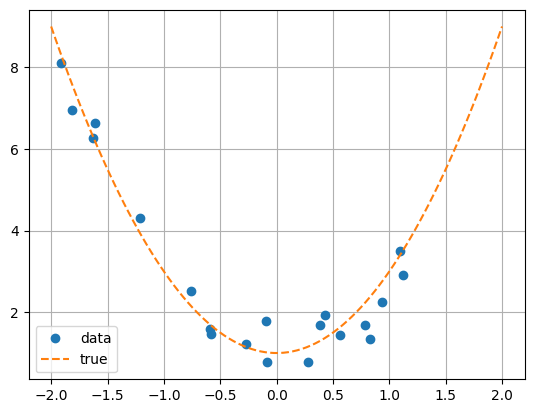

In [3]:
plt.plot(xs.detach().numpy(), ys.detach().numpy(), "o", label="data")
plt.plot(x.detach().numpy(), f(x).detach().numpy(), "--", label="true")
plt.legend()
plt.grid()
plt.show()

### Training loop

In [4]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.a = nn.Parameter(-2 * torch.ones(1))

    def forward(self, x: Tensor) -> Tensor:
        return 1 + self.a * x**2


def param_space(a: Tensor, model_a: Tensor, x: Tensor, y: Tensor) -> np.ndarray:
    loss_a: Tensor = (1 + a * x**2 - y * torch.ones_like(a)) ** 2
    loss_model_a: np.ndarray = ((1 + model_a * x**2 - y) ** 2).detach().numpy()
    fig, ax = plt.subplots()

    ax.scatter(model_a.detach().numpy(), loss_model_a, color="red")
    ax.plot(a.detach().numpy(), loss_a.detach().numpy())
    ax.set_ylim(0, 10)
    ax.grid()
    fig.canvas.draw()
    frame_image = np.array(fig.canvas.buffer_rgba())[..., :3]  # (H,W,3)  # type: ignore
    plt.ylim(0, 10)
    plt.close(fig)
    return frame_image


def train(
    model: Model,
    opt: torch.optim.Optimizer,
    loss_fn: nn.Module,
    data: tuple[Tensor, Tensor],
    epochs: int = 20,
    batch_size: int = 1,
    record_param: str = "",
):
    xs, ys = data
    N = xs.shape[0]
    model.train()
    losses: list[float] = []
    frames: list[np.ndarray] = []
    for epoch in range(epochs):
        perm = torch.randperm(N)  # shuffle for stochasticity each epoch
        loss = torch.tensor(torch.inf)
        for i in range(0, N, batch_size):
            batch_idx = perm[i : i + batch_size]
            x = xs[batch_idx]
            y = ys[batch_idx]

            opt.zero_grad()
            pred = model(x)
            loss = loss_fn(pred, y)
            loss.backward()
            if record_param != "":
                a = torch.linspace(-4, 4, 100, requires_grad=True)
                frame_image = param_space(a, model.a, xs[i], ys[i])
                frames.append(frame_image)
            opt.step()
        losses.append(loss.item())
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")
    if record_param != "":
        imageio.mimsave(record_param + ".mp4", frames, fps=20)  # type: ignore

        Video(record_param + ".mp4", embed=True, html_attributes="controls autoplay loop")

    return losses


def compare_losses(loss: list[float], nn_loss: list[float], title: str):
    plt.plot(nn_loss, linestyle="-", label="nn_loss")
    plt.plot(loss, linestyle="--", label="loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

## Parameters

In [5]:
lr = 0.0005
momentum = 0.9
dampening = 0.0
weight_decay = 0.0005
nesterov = False

record_name = ["full_batch_gd", "sgd", "mini_batch_gd"]
loss_fn = nn.MSELoss()

### 1. Full-Batch Gradient Descent

#### torch

In [6]:
model = Model()
opt = torch.optim.SGD(
    model.parameters(),
    lr=lr,
    momentum=momentum,
    dampening=dampening,
    weight_decay=weight_decay,
    nesterov=nesterov,
)
nn_loss = train(
    model, opt, loss_fn, (xs, ys), epochs=150, batch_size=N, record_param=record_name[0]
)

Epoch 1/150, Loss: 35.2975
Epoch 2/150, Loss: 35.1384
Epoch 3/150, Loss: 34.8374
Epoch 4/150, Loss: 34.4111
Epoch 5/150, Loss: 33.8755
Epoch 6/150, Loss: 33.2454
Epoch 7/150, Loss: 32.5349
Epoch 8/150, Loss: 31.7568
Epoch 9/150, Loss: 30.9232
Epoch 10/150, Loss: 30.0448
Epoch 11/150, Loss: 29.1316
Epoch 12/150, Loss: 28.1926
Epoch 13/150, Loss: 27.2356
Epoch 14/150, Loss: 26.2680
Epoch 15/150, Loss: 25.2959
Epoch 16/150, Loss: 24.3250
Epoch 17/150, Loss: 23.3602
Epoch 18/150, Loss: 22.4056
Epoch 19/150, Loss: 21.4649
Epoch 20/150, Loss: 20.5411
Epoch 21/150, Loss: 19.6369
Epoch 22/150, Loss: 18.7544
Epoch 23/150, Loss: 17.8953
Epoch 24/150, Loss: 17.0611
Epoch 25/150, Loss: 16.2527
Epoch 26/150, Loss: 15.4710
Epoch 27/150, Loss: 14.7165
Epoch 28/150, Loss: 13.9895
Epoch 29/150, Loss: 13.2901
Epoch 30/150, Loss: 12.6183
Epoch 31/150, Loss: 11.9738
Epoch 32/150, Loss: 11.3564
Epoch 33/150, Loss: 10.7656
Epoch 34/150, Loss: 10.2009
Epoch 35/150, Loss: 9.6618
Epoch 36/150, Loss: 9.1475
Epo

### custom

Epoch 1/150, Loss: 35.2975
Epoch 2/150, Loss: 35.1384
Epoch 3/150, Loss: 34.8374
Epoch 4/150, Loss: 34.4111
Epoch 5/150, Loss: 33.8755
Epoch 6/150, Loss: 33.2454
Epoch 7/150, Loss: 32.5349
Epoch 8/150, Loss: 31.7568
Epoch 9/150, Loss: 30.9232
Epoch 10/150, Loss: 30.0448
Epoch 11/150, Loss: 29.1316
Epoch 12/150, Loss: 28.1926
Epoch 13/150, Loss: 27.2356
Epoch 14/150, Loss: 26.2680
Epoch 15/150, Loss: 25.2959
Epoch 16/150, Loss: 24.3250
Epoch 17/150, Loss: 23.3602
Epoch 18/150, Loss: 22.4056
Epoch 19/150, Loss: 21.4649
Epoch 20/150, Loss: 20.5411
Epoch 21/150, Loss: 19.6369
Epoch 22/150, Loss: 18.7544
Epoch 23/150, Loss: 17.8953
Epoch 24/150, Loss: 17.0611
Epoch 25/150, Loss: 16.2527
Epoch 26/150, Loss: 15.4710
Epoch 27/150, Loss: 14.7165
Epoch 28/150, Loss: 13.9895
Epoch 29/150, Loss: 13.2901
Epoch 30/150, Loss: 12.6183
Epoch 31/150, Loss: 11.9738
Epoch 32/150, Loss: 11.3564
Epoch 33/150, Loss: 10.7656
Epoch 34/150, Loss: 10.2009
Epoch 35/150, Loss: 9.6618
Epoch 36/150, Loss: 9.1475
Epo

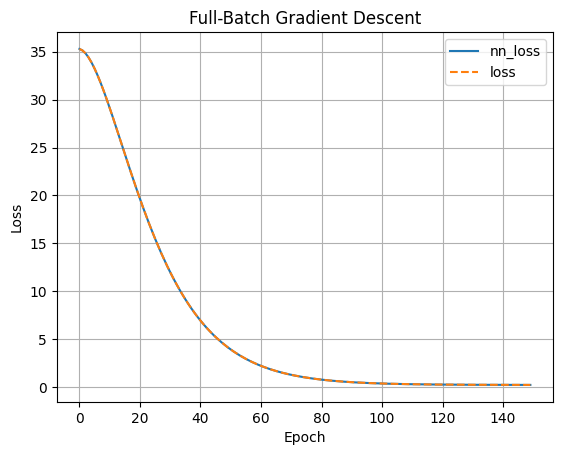

In [7]:
model = Model()
opt = mynn.SGD(
    model.parameters(),
    lr=lr,
    momentum=momentum,
    dampening=dampening,
    weight_decay=weight_decay,
    nesterov=nesterov,
)
loss = train(model, opt, loss_fn, (xs, ys), epochs=150, batch_size=N)
compare_losses(loss, nn_loss, "Full-Batch Gradient Descent")

# Evaluation

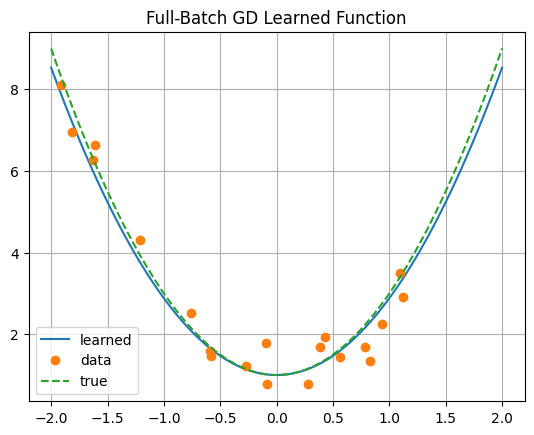

In [8]:
plt.plot(x_eval, model(x_eval[:, None]).squeeze().detach().numpy(), "-", label="learned")
plt.plot(xs.detach().numpy(), ys.detach().numpy(), "o", label="data")
plt.plot(x_eval, f(x_eval), "--", label="true")
plt.legend()
plt.title("Full-Batch GD Learned Function")
plt.grid()
plt.show()

### 2. Stochastic Gradient Descent

#### torch

In [9]:
torch.manual_seed(0)
model = Model()
opt = torch.optim.SGD(
    model.parameters(),
    lr=lr,
    momentum=momentum,
    dampening=dampening,
    weight_decay=weight_decay,
    nesterov=nesterov,
)

nn_loss = train(model, opt, loss_fn, (xs, ys), epochs=50, batch_size=1, record_param=record_name[1])

Epoch 1/50, Loss: 88.7415
Epoch 2/50, Loss: 0.2494
Epoch 3/50, Loss: 7.3649
Epoch 4/50, Loss: 3.7269
Epoch 5/50, Loss: 0.0332
Epoch 6/50, Loss: 0.1169
Epoch 7/50, Loss: 0.1609
Epoch 8/50, Loss: 0.3226
Epoch 9/50, Loss: 0.2014
Epoch 10/50, Loss: 0.0597
Epoch 11/50, Loss: 0.2531
Epoch 12/50, Loss: 0.1469
Epoch 13/50, Loss: 0.4198
Epoch 14/50, Loss: 0.5785
Epoch 15/50, Loss: 0.2296
Epoch 16/50, Loss: 0.2258
Epoch 17/50, Loss: 0.0063
Epoch 18/50, Loss: 0.0328
Epoch 19/50, Loss: 0.0110
Epoch 20/50, Loss: 0.1617
Epoch 21/50, Loss: 0.0177
Epoch 22/50, Loss: 0.0307
Epoch 23/50, Loss: 0.0318
Epoch 24/50, Loss: 0.4220
Epoch 25/50, Loss: 0.0597
Epoch 26/50, Loss: 0.1593
Epoch 27/50, Loss: 0.2665
Epoch 28/50, Loss: 0.1738
Epoch 29/50, Loss: 0.9858
Epoch 30/50, Loss: 0.9700
Epoch 31/50, Loss: 0.0034
Epoch 32/50, Loss: 0.3351
Epoch 33/50, Loss: 0.5785
Epoch 34/50, Loss: 0.0286
Epoch 35/50, Loss: 0.2501
Epoch 36/50, Loss: 0.0326
Epoch 37/50, Loss: 0.0009
Epoch 38/50, Loss: 0.0597
Epoch 39/50, Loss: 0

#### custom

In [10]:
torch.manual_seed(0)
model = Model()
opt = mynn.SGD(
    model.parameters(),
    lr=lr,
    momentum=momentum,
    dampening=dampening,
    weight_decay=weight_decay,
    nesterov=nesterov,
)

loss = train(model, opt, loss_fn, (xs, ys), epochs=50, batch_size=1)

Epoch 1/50, Loss: 88.7415
Epoch 2/50, Loss: 0.2494
Epoch 3/50, Loss: 7.3649
Epoch 4/50, Loss: 3.7269
Epoch 5/50, Loss: 0.0332
Epoch 6/50, Loss: 0.1169
Epoch 7/50, Loss: 0.1609
Epoch 8/50, Loss: 0.3226
Epoch 9/50, Loss: 0.2014
Epoch 10/50, Loss: 0.0597
Epoch 11/50, Loss: 0.2531
Epoch 12/50, Loss: 0.1469
Epoch 13/50, Loss: 0.4198
Epoch 14/50, Loss: 0.5785
Epoch 15/50, Loss: 0.2296
Epoch 16/50, Loss: 0.2258
Epoch 17/50, Loss: 0.0063
Epoch 18/50, Loss: 0.0328
Epoch 19/50, Loss: 0.0110
Epoch 20/50, Loss: 0.1617
Epoch 21/50, Loss: 0.0177
Epoch 22/50, Loss: 0.0307
Epoch 23/50, Loss: 0.0318
Epoch 24/50, Loss: 0.4220
Epoch 25/50, Loss: 0.0597
Epoch 26/50, Loss: 0.1593
Epoch 27/50, Loss: 0.2665
Epoch 28/50, Loss: 0.1738
Epoch 29/50, Loss: 0.9858
Epoch 30/50, Loss: 0.9700
Epoch 31/50, Loss: 0.0034
Epoch 32/50, Loss: 0.3351
Epoch 33/50, Loss: 0.5785
Epoch 34/50, Loss: 0.0286
Epoch 35/50, Loss: 0.2501
Epoch 36/50, Loss: 0.0326
Epoch 37/50, Loss: 0.0009
Epoch 38/50, Loss: 0.0597
Epoch 39/50, Loss: 0

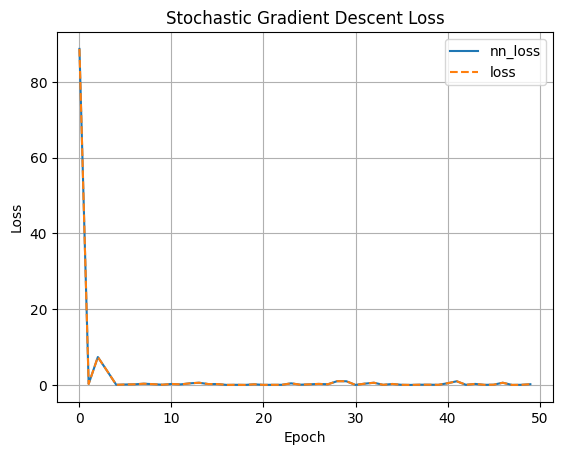

In [11]:
compare_losses(loss, nn_loss, "Stochastic Gradient Descent Loss")

# Evaluation

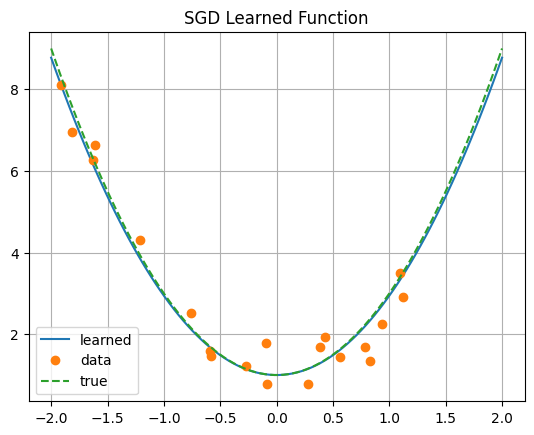

In [12]:
plt.plot(x_eval, model(x_eval[:, None]).squeeze().detach().numpy(), "-", label="learned")
plt.plot(xs.detach().numpy(), ys.detach().numpy(), "o", label="data")
plt.plot(x_eval, f(x_eval), "--", label="true")
plt.title("SGD Learned Function")
plt.legend()
plt.grid()
plt.show()

### 3. Mini-Batch Gradient Descent

#### torch

In [13]:
torch.manual_seed(0)
model = Model()
opt = torch.optim.SGD(
    model.parameters(),
    lr=lr,
    momentum=momentum,
    dampening=dampening,
    weight_decay=weight_decay,
    nesterov=nesterov,
)

nn_loss = train(model, opt, loss_fn, (xs, ys), epochs=20, batch_size=4, record_param=record_name[2])

Epoch 1/20, Loss: 42.9919
Epoch 2/20, Loss: 4.9880
Epoch 3/20, Loss: 31.0263
Epoch 4/20, Loss: 31.2081
Epoch 5/20, Loss: 7.8520
Epoch 6/20, Loss: 2.4831
Epoch 7/20, Loss: 10.6862
Epoch 8/20, Loss: 10.8539
Epoch 9/20, Loss: 0.7065
Epoch 10/20, Loss: 0.1351
Epoch 11/20, Loss: 8.7555
Epoch 12/20, Loss: 0.2808
Epoch 13/20, Loss: 3.3192
Epoch 14/20, Loss: 0.1825
Epoch 15/20, Loss: 0.0179
Epoch 16/20, Loss: 0.1715
Epoch 17/20, Loss: 1.5511
Epoch 18/20, Loss: 0.4128
Epoch 19/20, Loss: 0.3955
Epoch 20/20, Loss: 0.3882


#### custom

In [14]:
torch.manual_seed(0)
model = Model()
opt = mynn.SGD(
    model.parameters(),
    lr=lr,
    momentum=momentum,
    dampening=dampening,
    weight_decay=weight_decay,
    nesterov=nesterov,
)

loss = train(model, opt, loss_fn, (xs, ys), epochs=20, batch_size=4)

Epoch 1/20, Loss: 42.9919
Epoch 2/20, Loss: 4.9880
Epoch 3/20, Loss: 31.0263
Epoch 4/20, Loss: 31.2081
Epoch 5/20, Loss: 7.8520
Epoch 6/20, Loss: 2.4831
Epoch 7/20, Loss: 10.6862
Epoch 8/20, Loss: 10.8539
Epoch 9/20, Loss: 0.7065
Epoch 10/20, Loss: 0.1351
Epoch 11/20, Loss: 8.7555
Epoch 12/20, Loss: 0.2808
Epoch 13/20, Loss: 3.3192
Epoch 14/20, Loss: 0.1825
Epoch 15/20, Loss: 0.0179
Epoch 16/20, Loss: 0.1715
Epoch 17/20, Loss: 1.5511
Epoch 18/20, Loss: 0.4128
Epoch 19/20, Loss: 0.3955
Epoch 20/20, Loss: 0.3882


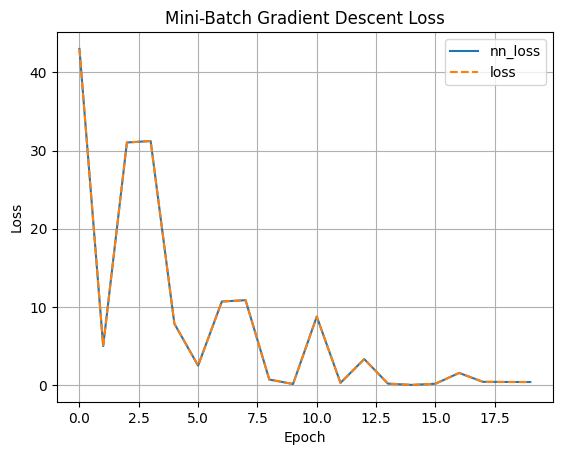

In [15]:
compare_losses(loss, nn_loss, "Mini-Batch Gradient Descent Loss")

# Evaluation

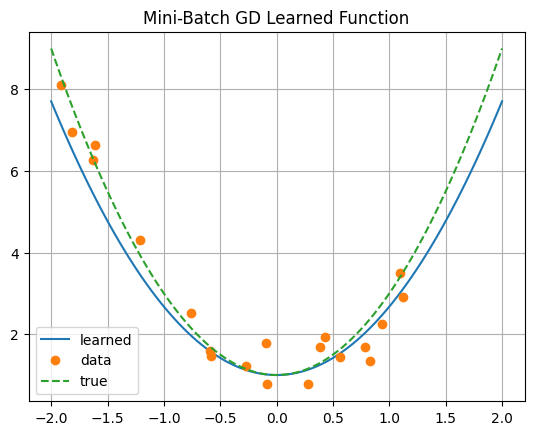

In [16]:
plt.plot(x_eval, model(x_eval[:, None]).squeeze().detach().numpy(), "-", label="learned")
plt.plot(xs.detach().numpy(), ys.detach().numpy(), "o", label="data")
plt.plot(x_eval, f(x_eval), "--", label="true")
plt.title("Mini-Batch GD Learned Function")
plt.legend()
plt.grid()
plt.show()